# Experiment No 8

**Aim:** To implement K-Means and Hierarchical Clustering algorithms on a loan dataset to identify patterns among borrowers.

**Dataset:** `loan_data.csv` — LendingClub loan records with features including interest rate, FICO score, debt-to-income ratio, and repayment status.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

df = pd.read_csv('./data/loan_data.csv')
display(df.head(3))
print(df.shape)

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0


(9578, 14)


### Preprocessing

In [3]:
# Encode categorical 'purpose' column
le = LabelEncoder()
df['purpose_enc'] = le.fit_transform(df['purpose'])

features = ['int.rate','installment','log.annual.inc','dti',
            'fico','revol.bal','revol.util','inq.last.6mths',
            'delinq.2yrs','pub.rec','purpose_enc']

X = df[features].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f'Variance explained by 2 PCs: {pca.explained_variance_ratio_.sum()*100:.2f}%')

Variance explained by 2 PCs: 38.45%


### K-Means – Optimal K via Elbow Method & Silhouette Score

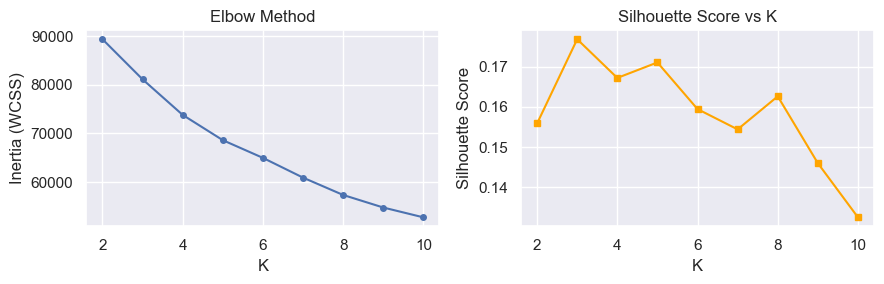

In [4]:
k_range = range(2, 11)
inertias, silhouettes = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].plot(k_range, inertias, marker='o', markersize=4)
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method')

axes[1].plot(k_range, silhouettes, marker='s', color='orange', markersize=4)
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs K')

plt.tight_layout(); plt.show()

### K-Means – Fit & Visualise

,K,Inertia,Silhouette Score
0,3,81122.6454,0.1768


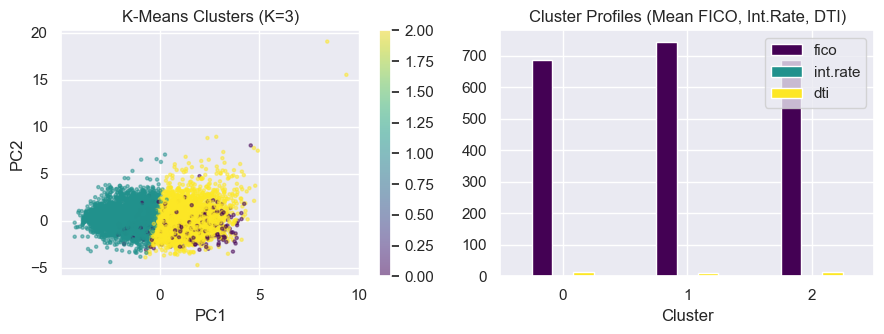

In [5]:
best_k = 3  # adjust based on elbow/silhouette plots above
km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
km_labels = km.fit_predict(X_scaled)

display(pd.DataFrame({
    'K': [best_k],
    'Inertia':         [km.inertia_],
    'Silhouette Score': [silhouette_score(X_scaled, km_labels)]
}).round(4))

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

sc = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=km_labels,
                     cmap='viridis', s=5, alpha=0.5)
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].set_title(f'K-Means Clusters (K={best_k})')
plt.colorbar(sc, ax=axes[0])

# Cluster profile – mean FICO and interest rate per cluster
df_plot = X.copy()
df_plot['cluster'] = km_labels
cluster_means = df_plot.groupby('cluster')[['fico','int.rate','dti']].mean()
cluster_means.plot(kind='bar', ax=axes[1], colormap='viridis', legend=True)
axes[1].set_title('Cluster Profiles (Mean FICO, Int.Rate, DTI)')
axes[1].set_xlabel('Cluster'); axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout(); plt.show()

### Hierarchical Clustering – Dendrogram

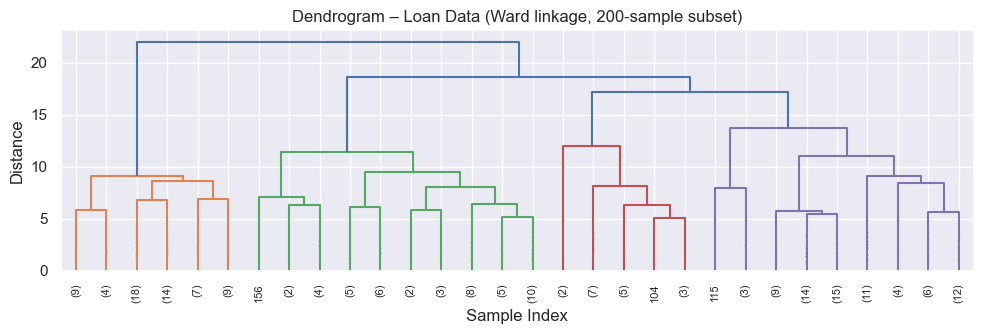

In [6]:
sample_idx = np.random.RandomState(42).choice(len(X_scaled), 200, replace=False)
Z = linkage(X_scaled[sample_idx], method='ward')

fig, ax = plt.subplots(figsize=(10, 3.5))
dendrogram(Z, ax=ax, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=8, show_contracted=True)
ax.set_title('Dendrogram – Loan Data (Ward linkage, 200-sample subset)')
ax.set_xlabel('Sample Index'); ax.set_ylabel('Distance')
plt.tight_layout(); plt.show()

### Hierarchical Clustering – Fit & Visualise

,K,Silhouette Score
0,3,0.1155


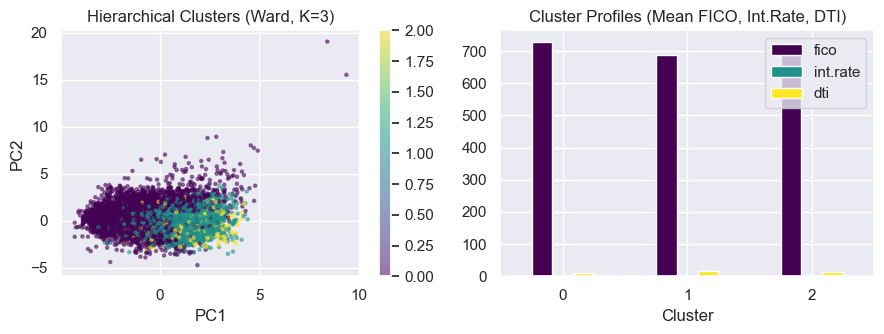

In [7]:
agg = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
agg_labels = agg.fit_predict(X_scaled)

display(pd.DataFrame({
    'K': [best_k],
    'Silhouette Score': [silhouette_score(X_scaled, agg_labels)]
}).round(4))

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

sc2 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=agg_labels,
                      cmap='viridis', s=5, alpha=0.5)
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].set_title(f'Hierarchical Clusters (Ward, K={best_k})')
plt.colorbar(sc2, ax=axes[0])

df_plot2 = X.copy()
df_plot2['cluster'] = agg_labels
cluster_means2 = df_plot2.groupby('cluster')[['fico','int.rate','dti']].mean()
cluster_means2.plot(kind='bar', ax=axes[1], colormap='viridis', legend=True)
axes[1].set_title('Cluster Profiles (Mean FICO, Int.Rate, DTI)')
axes[1].set_xlabel('Cluster'); axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout(); plt.show()

## Conclusion

Both K-Means and Hierarchical Clustering (Ward linkage) segment loan applicants into distinct groups based on financial attributes. The cluster profile plots reveal meaningful differences in FICO score, interest rate, and debt-to-income ratio across segments, demonstrating the value of unsupervised learning for borrower profiling.